In [50]:
# ==============================================================
#  Hybrid Battery SoC Estimator using LSTM
# ==============================================================
# Description: Physics-informed ML SoC estimator combining
# voltage, current, and temperature time series.
# ==============================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from sklearn.preprocessing import MinMaxScaler

In [67]:
def load_battery_tests(folder_path, ocv_file_path, capacity_Ah,
                       current_threshold=0.1, rest_threshold_h=1.0):
    """
    Reads all Excel battery test files (recursively) and extracts sheets named 'Detail_*'.
    Computes Time and SOC via vectorized cumtrapz integration.
    SOC resets during relaxation periods (no current for >= 1 hour).
    Adds a Source Index for each file.

    Parameters
    ----------
    folder_path : str
        Path to folder containing test files.
    ocv_file_path : str
        Path to the OCV Excel file (sheet 'Averaged') with columns ['SOC', 0, 10, 25, 35, 45].
    capacity_Ah : float
        Nominal cell capacity in Ah.
    current_threshold : float, optional
        Current (A) below which the cell is considered resting. Default is 0.1 A.
    rest_threshold_h : float, optional
        Minimum rest duration (hours) to trigger an SOC reset. Default is 1 hour.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame containing all processed test data.
    """

    # --- Read OCV curve from "Averaged" sheet ---
    ocv_raw = pd.read_excel(ocv_file_path, sheet_name="Averaged")
    ocv_raw.columns = [str(c).strip() for c in ocv_raw.columns]

    if "SOC" not in ocv_raw.columns:
        raise ValueError("OCV sheet must contain 'SOC' column.")

    temp_col = next((c for c in ocv_raw.columns if c.strip() in ["25", "25.0"]), None)
    if temp_col is None:
        raise ValueError(f"Could not find '25' column in OCV file. Found: {ocv_raw.columns.tolist()}")

    ocv_curve = ocv_raw[["SOC", temp_col]].rename(columns={temp_col: "Voltage"}).dropna()
    ocv_curve = ocv_curve.sort_values("Voltage").reset_index(drop=True)

    # --- Columns of interest in test files ---
    cols = ["Current(A)", "Voltage(V)", "Capacity(Ah)", "Relative Time(h:min:s.ms)"]
    all_data = []
    file_index = 0

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith((".xlsx", ".xls")):
                file_path = os.path.join(root, file)
                file_index += 1

                try:
                    xls = pd.ExcelFile(file_path)
                except Exception as e:
                    print(f"⚠️ Could not open {file_path}: {e}")
                    continue

                for sheet in xls.sheet_names:
                    if re.match(r"Detail_.*", sheet):
                        try:
                            df = pd.read_excel(file_path, sheet_name=sheet, usecols=cols)
                        except Exception as e:
                            print(f"⚠️ Failed reading {sheet} in {file}: {e}")
                            continue

                        # --- Parse Relative Time ---
                        def parse_rel_time(t):
                            try:
                                h, m, s = re.split('[:_]', str(t))
                                return int(h)*3600 + int(m)*60 + float(s)
                            except Exception:
                                return np.nan

                        df["RelTime_s"] = df["Relative Time(h:min:s.ms)"].astype(str).apply(parse_rel_time)

                        # --- Continuous Time ---
                        time_vals = [0]
                        for i in range(1, len(df)):
                            curr = df["RelTime_s"].iloc[i]
                            prev = df["RelTime_s"].iloc[i - 1]
                            if curr < prev or np.isnan(curr) or np.isnan(prev):
                                time_vals.append(time_vals[-1] + 0.1)
                            else:
                                time_vals.append(time_vals[-1] + (curr - prev))
                        df["Time"] = time_vals

                        # --- Initial SOC from OCV ---
                        v0 = df["Voltage(V)"].iloc[0]
                        soc0 = np.interp(v0, ocv_curve["Voltage"], ocv_curve["SOC"])

                        # --- SOC ---
                        time_h = np.array(df["Time"]) / 3600  # convert to hours
                        current = np.array(df["Current(A)"])

                        dAh_cumulative = np.insert(cumulative_trapezoid(current, time_h), 0, 0)
                        soc = soc0 + dAh_cumulative / capacity_Ah

                        # # --- SOC reset during long rest periods ---
                        # resting = np.abs(current) < current_threshold
                        # # find consecutive resting segments
                        # rest_starts = np.where(np.diff(np.insert(resting.astype(int), 0, 0)) == 1)[0]
                        # rest_ends = np.where(np.diff(np.append(resting.astype(int), 0)) == -1)[0]

                        # for start, end in zip(rest_starts, rest_ends):
                        #     duration_h = (time_h[end] - time_h[start])
                        #     if duration_h >= rest_threshold_h:
                        #         v_rest = df["Voltage(V)"].iloc[start:end].mean()
                        #         soc_reset = np.interp(v_rest, ocv_curve["Voltage"], ocv_curve["SOC"])
                        #         soc[start:end] = soc_reset
                        #         soc[end:] = soc[end:] - soc[end] + soc_reset  # continue from reset

                        # --- Clamp SOC ---
                        # soc[df["Voltage(V)"] <= 2.8] = 0
                        # soc = np.clip(soc, 0, 100)
                        df["SOC"] = soc

                        # --- Add metadata ---
                        df["Source File"] = file
                        df["Source Index"] = file_index

                        all_data.append(df)

    # Combine all files
    if all_data:
        df_all = pd.concat(all_data, ignore_index=True)
    else:
        df_all = pd.DataFrame()

    return df_all


In [68]:
# Run the data extraction
ocv_file = r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Zeleros - Zeleros\Operaciones\4- E-drive\05- Projects\Meridian\05_Engineering_Design\02_Module\00_Cell\02_Modelling\Updated_parameters\OCV.xlsx"
folder = r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Zeleros - Zeleros\Operaciones\4- E-drive\05- Projects\Meridian\02_SE\03_Testing_&_Validations\Caracterización_Eléctrica_Termica\01_Results\01_Capacity\25 ºC"
capacity = 116  # Ah
df = load_battery_tests(folder, ocv_file, capacity)

df


,Current(A),Voltage(V),Capacity(Ah),Relative Time(h:min:s.ms),RelTime_s,Time,SOC,Source File,Source Index
0,0.00000,4.2164,0.000000,0:00:00.000,0.0,0.0,0.989127,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
1,0.00000,4.2164,0.000000,0:00:05.000,5.0,5.0,0.989127,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
2,29.13083,4.2718,0.000000,0:00:00.000,0.0,5.1,0.989130,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
3,16.57033,4.2551,0.047983,0:00:10.000,10.0,15.1,0.989677,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
4,16.02834,4.2567,0.093219,0:00:20.000,20.0,25.1,0.990068,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
...,...,...,...,...,...,...,...,...,...
29739,0.00000,3.0576,0.000000,0:59:56.000,3596.0,16312.9,-0.026262,ME-ITE-250223-02_CapacityTest_25oC.xlsx,2
29740,0.00000,3.0575,0.000000,0:59:57.000,3597.0,16313.9,-0.026262,ME-ITE-250223-02_CapacityTest_25oC.xlsx,2
29741,0.00000,3.0575,0.000000,0:59:58.000,3598.0,16314.9,-0.026262,ME-ITE-250223-02_CapacityTest_25oC.xlsx,2
29742,0.00000,3.0575,0.000000,0:59:59.000,3599.0,16315.9,-0.026262,ME-ITE-250223-02_CapacityTest_25oC.xlsx,2


In [63]:
def plot_battery_data(df, title="Battery Test Data"):
    """
    Creates a 2-row subplot:
      - Top: Voltage and Current vs Time
      - Bottom: SOC vs Time
    """

    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'hspace': 0.1})

    # --- Top subplot: Voltage and Current ---
    ax1 = axs[0]
    ax1.plot(df["Time"], df["Voltage(V)"], color='tab:blue', label='Voltage (V)')
    ax1.set_ylabel("Voltage (V)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Create secondary y-axis for current
    ax2 = ax1.twinx()
    ax2.plot(df["Time"], df["Current(A)"], color='tab:orange', label='Current (A)')
    ax2.set_ylabel("Current (A)", color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Add title
    ax1.set_title(title)

    # --- Bottom subplot: SOC ---
    axs[1].plot(df["Time"], df["SOC"], color='tab:green', label='SOC (%)')
    axs[1].set_ylabel("SOC (%)")
    axs[1].set_xlabel("Time (s)")

    # --- Grid and labels ---
    for ax in axs:
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()


C:\Users\mmackenzie\AppData\Local\Temp\ipykernel_83156\2976871841.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


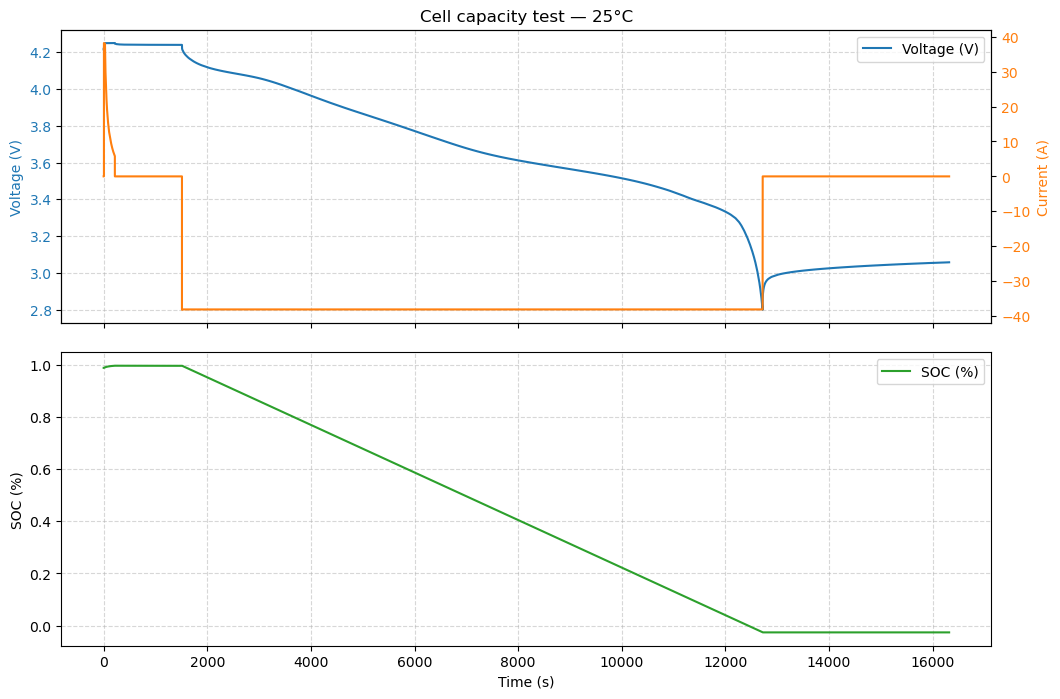

In [65]:
# Assuming df is your processed test data
data = df.loc[df["Source Index"] == 2]
plot_battery_data(data, title="Cell capacity test — 25°C")


In [69]:
# --- Step 1: Preprocessing ---
# Sort by time and reset index
data_df = df.loc[df["Source Index"] == 1].sort_values('Time').reset_index(drop=True)
data_df

,Current(A),Voltage(V),Capacity(Ah),Relative Time(h:min:s.ms),RelTime_s,Time,SOC,Source File,Source Index
0,0.00000,4.2164,0.000000,0:00:00.000,0.0,0.0,0.989127,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
1,0.00000,4.2164,0.000000,0:00:05.000,5.0,5.0,0.989127,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
2,29.13083,4.2718,0.000000,0:00:00.000,0.0,5.1,0.989130,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
3,16.57033,4.2551,0.047983,0:00:10.000,10.0,15.1,0.989677,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
4,16.02834,4.2567,0.093219,0:00:20.000,20.0,25.1,0.990068,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
...,...,...,...,...,...,...,...,...,...
14861,0.00000,3.0598,0.000000,0:59:56.000,3596.0,16303.2,-0.024396,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
14862,0.00000,3.0598,0.000000,0:59:57.000,3597.0,16304.2,-0.024396,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
14863,0.00000,3.0598,0.000000,0:59:58.000,3598.0,16305.2,-0.024396,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1
14864,0.00000,3.0598,0.000000,0:59:59.000,3599.0,16306.2,-0.024396,ME-ITE-250223-01_CapacityTest_25oC.xlsx,1


In [82]:
# Feature scaling (neural nets perform better with normalized inputs)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_features = data_df[['Voltage(V)', 'Current(A)']].values
y_soc = data_df[['SOC']].values

X_scaled = scaler_x.fit_transform(X_features)
y_scaled = scaler_y.fit_transform(y_soc)
X_scaled

array([[0.96235902, 0.56742357],
       [0.96235902, 0.56742357],
       [1.        , 1.        ],
       ...,
       [0.17651855, 0.56742357],
       [0.17651855, 0.56742357],
       [0.17651855, 0.56742357]])

In [77]:
# --- Step 2: Create sequence windows ---
def create_sequences(X, y, window_size=20):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

window_size = 20  # ~20 time steps (e.g., 1-2 seconds)
X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size)

print(f"Data shape: X_seq={X_seq.shape}, y_seq={y_seq.shape}")

Data shape: X_seq=(14846, 20, 2), y_seq=(14846, 1)


In [83]:
# --- Step 3: Train/test split ---
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [84]:
# --- Step 4: Define LSTM Model ---
class SoC_LSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # use last hidden state
        return out

model = SoC_LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [85]:
# --- Step 5: Train ---
epochs = 50
train_loss = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.5f}")

Epoch 0/50, Loss: 0.25056
Epoch 10/50, Loss: 0.12590
Epoch 20/50, Loss: 0.08124
Epoch 30/50, Loss: 0.06443
Epoch 40/50, Loss: 0.05378


In [86]:
# --- Step 6: Evaluate ---
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test).numpy()
    y_true_test = y_test.numpy()

# Invert normalization
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test)
y_true_test_inv = scaler_y.inverse_transform(y_true_test)

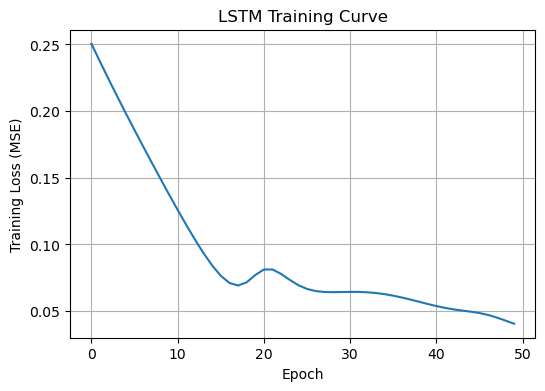

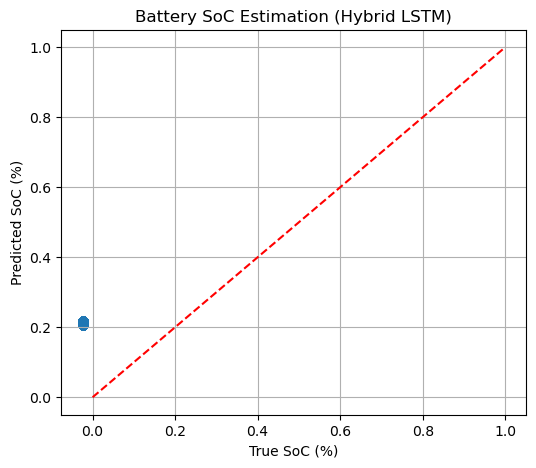

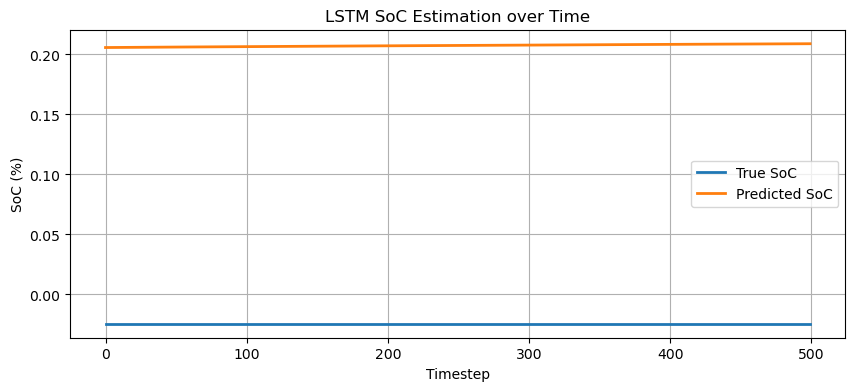

In [89]:
# --- Step 7: Visualization ---
plt.figure(figsize=(6,4))
plt.plot(train_loss)
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('LSTM Training Curve')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(y_true_test_inv, y_pred_test_inv, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('True SoC (%)')
plt.ylabel('Predicted SoC (%)')
plt.title('Battery SoC Estimation (Hybrid LSTM)')
plt.grid(True)
plt.show()

# --- Step 8: Plot time series comparison ---
plt.figure(figsize=(10,4))
plt.plot(y_true_test_inv[:500], label='True SoC', linewidth=2)
plt.plot(y_pred_test_inv[:500], label='Predicted SoC', linewidth=2)
plt.xlabel('Timestep')
plt.ylabel('SoC (%)')
plt.title('LSTM SoC Estimation over Time')
plt.legend()
plt.grid(True)
plt.show()